# K-MEANS

Neste trabalho será utilizado o algoritmo K-Means para realizar agrupamento de dados no conjunto Breast Cancer Wisconsin.

O objetivo é verificar como diferentes modificações nos atributos influenciam a qualidade dos grupos encontrados.

Como o K-Means é um algoritmo de aprendizado não supervisionado, ele não utiliza a informação de diagnóstico durante o treinamento. O algoritmo tenta encontrar grupos naturalmente presentes nos dados.

Para avaliar os agrupamentos serão utilizadas três métricas:

- Silhouette Score
- Calinski-Harabasz
- Davies-Bouldin

Também serão utilizados gráficos para visualizar os clusters encontrados.

# Importação das Bibliotecas

Nesta etapa importamos as bibliotecas que serão utilizadas durante o trabalho.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# Leitura do Dataset

Nesta etapa carregamos o conjunto de dados Breast Cancer Wisconsin.

In [4]:
df = pd.read_csv("data.csv")

# Análise do Dataset

Antes de aplicar qualquer técnica de aprendizado de máquina é importante observar os dados.

A função head() exibe as primeiras linhas do conjunto e permite verificar:

- Quais atributos existem
- Como os dados estão organizados
- Se existe algum problema visível

In [5]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


A função info() apresenta informações importantes sobre o conjunto de dados.

Ela permite verificar:

- Quantidade de registros
- Quantidade de atributos
- Tipos de dados
- Existência de valores nulos

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

A função describe() calcula medidas estatísticas para cada atributo.

Entre elas:

- Média
- Desvio padrão
- Valor mínimo
- Valor máximo
- Quartis

In [7]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


# Limpeza dos Dados

Nem todos os atributos são úteis para o agrupamento.

O atributo id funciona apenas como um identificador e não possui nenhum significado sobre os tumores.

O atributo Unnamed: 32 está vazio e não fornece qualquer informação relevante.

Por esse motivo ambos serão removidos antes dos experimentos.

In [8]:
df = df.drop(columns=["id", "Unnamed: 32"])

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


# K-Means

### Cenário 1: Preparação do Conjunto Original

Este será nosso cenário de referência.

Serão utilizados todos os atributos disponíveis após a limpeza dos dados.

O atributo diagnosis será removido, pois representa apenas o rótulo conhecido e não deve participar do agrupamento.

In [9]:
X = df.drop(columns=["diagnosis"])

X.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Cenário 2: Remoção do Radius_Worst e do Texture_Worst

Serão removidos os atributos:

- radius_worst
- texture_worst

O objetivo é verificar se essas características possuem influência significativa na formação dos grupos.

In [10]:
X_sem_dois = df.drop(
    columns=[
        "diagnosis",
        "radius_worst",
        "texture_worst"
    ]
)

### Cenário 3: Apenas Atributos Mean

Neste experimento serão utilizados apenas atributos que representam médias das medições realizadas.

O objetivo é verificar se apenas as características médias conseguem representar adequadamente os tumores.

In [11]:
mean_cols = [c for c in df.columns if "mean" in c]

X_mean = df[mean_cols]

### Cenário 4: Apenas Atributos Worst

Neste cenário serão utilizados apenas atributos que representam os maiores valores observados.

Esses atributos normalmente destacam características mais agressivas dos tumores.

O objetivo é verificar se eles possuem maior capacidade de separação dos grupos.

In [12]:
worst_cols = [c for c in df.columns if "worst" in c]

X_worst = df[worst_cols]

### Padronização

O algoritmo K-Means utiliza distância Euclidiana para calcular a proximidade entre os exemplos.

Como os atributos possuem escalas diferentes, alguns deles poderiam influenciar excessivamente o cálculo das distâncias.

Para evitar esse problema utilizamos o StandardScaler.

Após a transformação, todos os atributos passam a ter a mesma importância nos cálculos.

In [13]:
scaler = StandardScaler()

X_original_scaled = scaler.fit_transform(X)
X_sem_dois_scaled = scaler.fit_transform(X_sem_dois)
X_mean_scaled = scaler.fit_transform(X_mean)
X_worst_scaled = scaler.fit_transform(X_worst)

### Aplicação do K-means

O algoritmo K-Means divide os dados em grupos de acordo com a proximidade entre os exemplos.

Foi definido:

- k = 2 grupos
- random_state = 42
- n_init = 10

O valor 2 foi escolhido porque o conjunto de dados está relacionado a tumores benignos e malignos.

In [14]:
def executar_kmeans(X):

    modelo = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    clusters = modelo.fit_predict(X)

    return modelo, clusters

### Treinamento dos Cenários

Agora o algoritmo será executado para cada cenário criado.

O objetivo é comparar posteriormente a qualidade dos agrupamentos encontrados.

In [15]:
km_original, c_original = executar_kmeans(X_original_scaled)

km_sem_dois, c_sem_dois = executar_kmeans(X_sem_dois_scaled)

km_mean, c_mean = executar_kmeans(X_mean_scaled)

km_worst, c_worst = executar_kmeans(X_worst_scaled)

### Avaliação

Para comparar os diferentes cenários serão utilizadas três métricas.

- Silhouette Score: mede o quão separados estão os grupos.
- Calinski-Harabasz: mede a separação entre os clusters.
- Davies-Bouldin: mede a semelhança entre os grupos.

Quanto maior forem os valores de Silhouette e Calinski-Harabasz, melhor.

Quanto menor for o Davies-Bouldin, melhor.

In [16]:
def avaliar(X, clusters):

    return {
        "Silhouette": silhouette_score(X, clusters),
        "Calinski": calinski_harabasz_score(X, clusters),
        "Davies": davies_bouldin_score(X, clusters)
    }

### Benchmark

Nesta etapa será realizada a comparação entre todos os cenários criados.

A tabela permitirá identificar quais conjuntos de atributos geram os melhores agrupamentos.

In [17]:
resultados = pd.DataFrame({

    "Original":
        avaliar(X_original_scaled, c_original),

    "Sem 2 atributos":
        avaliar(X_sem_dois_scaled, c_sem_dois),

    "Apenas Mean":
        avaliar(X_mean_scaled, c_mean),

    "Apenas Worst":
        avaliar(X_worst_scaled, c_worst)
}).T

resultados

,Silhouette,Calinski,Davies
Original,0.343382,267.691716,1.320510
Sem 2 atributos,0.349008,267.888539,1.313141
Apenas Mean,0.394593,359.681395,1.106260
Apenas Worst,0.414231,415.665017,1.061622


Como o conjunto possui muitas dimensões, não é possível visualizar diretamente os agrupamentos.

O PCA será utilizado para reduzir os dados para duas dimensões.

Dessa forma será possível observar visualmente como o algoritmo separou os exemplos.

In [18]:
def plot_clusters(X, clusters, diagnosis, titulo):

    # Descobre qual cluster possui mais benignos
    tabela = pd.crosstab(diagnosis, clusters)

    cluster_benigno = tabela.loc["B"].idxmax()

    # Reorganiza os clusters
    clusters_ajustados = np.where(
        clusters == cluster_benigno,
        0,  # Benigno
        1   # Maligno
    )

    # PCA para visualização
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    # Azul = Benigno | Vermelho = Maligno
    cmap = ListedColormap(["royalblue", "crimson"])

    plt.figure(figsize=(8,6))

    plt.scatter(
        X_pca[:,0],
        X_pca[:,1],
        c=clusters_ajustados,
        cmap=cmap,
    )

    legenda = [
        Patch(color="royalblue", label="Cluster predominantemente Benigno"),
        Patch(color="crimson", label="Cluster predominantemente Maligno")
    ]

    plt.legend(handles=legenda)

    plt.title(titulo)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")

    plt.show()

### Gráficos

Os gráficos a seguir mostram a distribuição dos clusters encontrados pelo algoritmo K-Means em cada cenário.

Quanto mais separados os grupos estiverem, melhor tende a ser a qualidade do agrupamento.

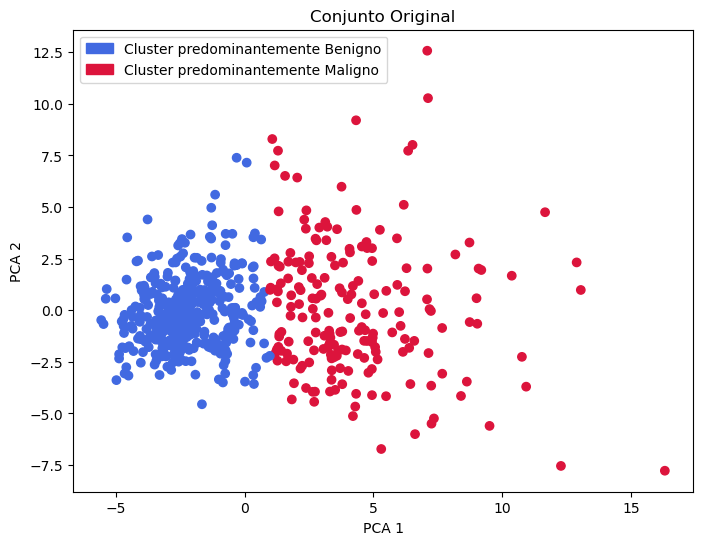

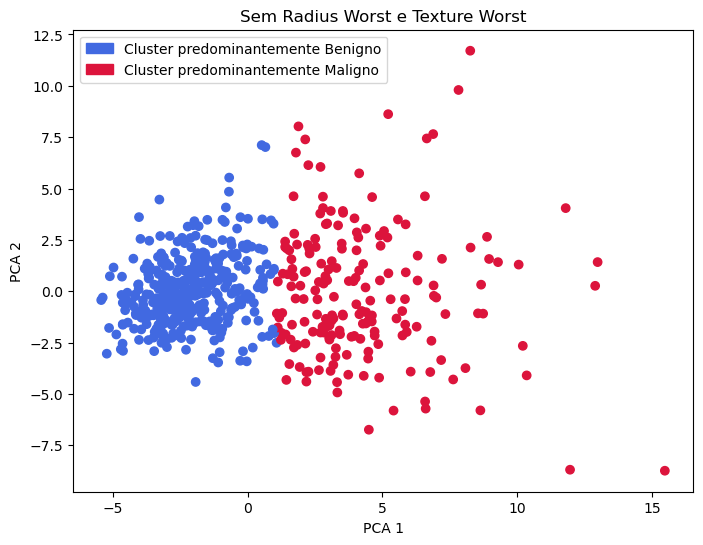

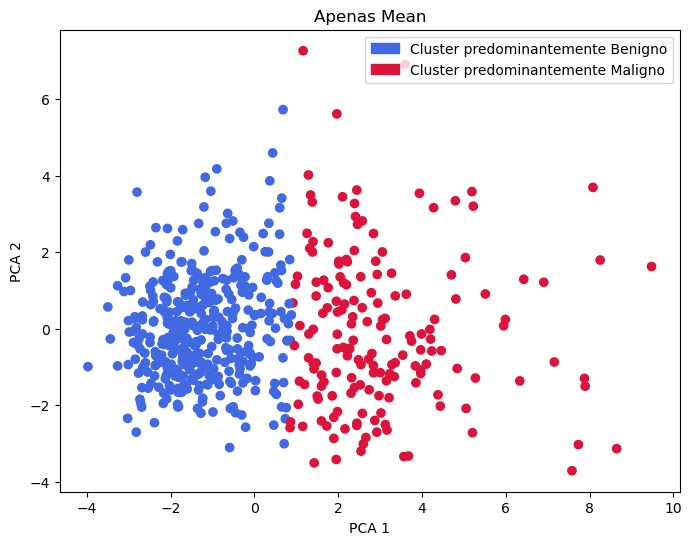

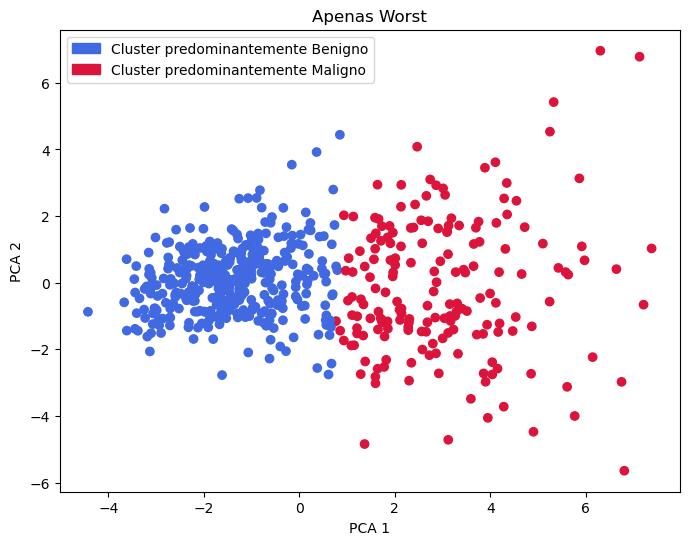

In [19]:
plot_clusters(
    X_original_scaled,
    c_original,
    df["diagnosis"],
    "Conjunto Original"
)

plot_clusters(
    X_sem_dois_scaled,
    c_sem_dois,
    df["diagnosis"],
    "Sem Radius Worst e Texture Worst"
)

plot_clusters(
    X_mean_scaled,
    c_mean,
    df["diagnosis"],
    "Apenas Mean"
)

plot_clusters(
    X_worst_scaled,
    c_worst,
    df["diagnosis"],
    "Apenas Worst"
)

### Comparação dos Cluster com o Cenário Real

Até este ponto foram avaliadas apenas métricas internas dos agrupamentos, como Silhouette Score, Calinski-Harabasz e Davies-Bouldin.

Embora essas métricas indiquem a qualidade dos clusters, elas não mostram se os grupos encontrados possuem relação com os diagnósticos reais dos pacientes.

Por esse motivo será realizada uma comparação entre os clusters produzidos pelo K-Means e a coluna diagnosis do conjunto de dados.

É importante lembrar que o diagnóstico não foi utilizado durante o treinamento do algoritmo. Ele será utilizado apenas para análise dos resultados.

Se a maior parte dos tumores benignos ficar concentrada em um cluster e a maior parte dos tumores malignos em outro, isso indica que o algoritmo conseguiu identificar padrões relevantes nos dados.

In [20]:
cenarios = {
    "Original": c_original,
    "Sem 2 atributos": c_sem_dois,
    "Apenas Mean": c_mean,
    "Apenas Worst": c_worst
}

for nome, clusters in cenarios.items():

    # Cria a tabela original
    tabela = pd.crosstab(
        df["diagnosis"],
        clusters
    )

    # Descobre qual cluster possui mais benignos
    cluster_benigno = tabela.loc["B"].idxmax()

    # Se necessário, inverte os rótulos
    if cluster_benigno == 1:
        clusters = np.where(clusters == 0, 1, 0)

    print(f"\n{'='*50}")
    print(f"CENÁRIO: {nome}")
    print(f"{'='*50}")

    tabela = pd.crosstab(
        df["diagnosis"],
        clusters
    )

    print(tabela)


CENÁRIO: Original
col_0        0    1
diagnosis          
B          339   18
M           36  176

CENÁRIO: Sem 2 atributos
col_0        0    1
diagnosis          
B          340   17
M           40  172

CENÁRIO: Apenas Mean
col_0        0    1
diagnosis          
B          351    6
M           49  163

CENÁRIO: Apenas Worst
col_0        0    1
diagnosis          
B          350    7
M           37  175


In [21]:
print("Quantidade real de Benignos e Malignos:")
df["diagnosis"].value_counts()

Quantidade real de Benignos e Malignos:


diagnosis
B    357
M    212
Name: count, dtype: int64

As tabelas apresentadas mostram quantos tumores benignos e malignos foram agrupados em cada cluster.

O objetivo é verificar se existe uma correspondência entre os grupos encontrados pelo K-Means e os diagnósticos reais do conjunto de dados.

Quanto maior for a concentração de um único diagnóstico em cada cluster, melhor será a separação produzida pelo algoritmo.

In [22]:
for nome, clusters in cenarios.items():

    print(f"\n{'='*50}")
    print(f"PERCENTUAIS - {nome}")
    print(f"{'='*50}")

    tabela = pd.crosstab(
        df["diagnosis"],
        clusters
    )

    tabela_percentual = (
        tabela.div(tabela.sum(axis=1), axis=0)
        * 100
    )

    print(tabela_percentual.round(2))


PERCENTUAIS - Original
col_0          0      1
diagnosis              
B          94.96   5.04
M          16.98  83.02

PERCENTUAIS - Sem 2 atributos
col_0          0      1
diagnosis              
B           4.76  95.24
M          81.13  18.87

PERCENTUAIS - Apenas Mean
col_0          0      1
diagnosis              
B          98.32   1.68
M          23.11  76.89

PERCENTUAIS - Apenas Worst
col_0          0      1
diagnosis              
B           1.96  98.04
M          82.55  17.45


Agora, fazemos a soma dos erros em cada cenário:

In [23]:
for nome, clusters in cenarios.items():

    tabela = pd.crosstab(
        df["diagnosis"],
        clusters
    )

    erros = 0

    for cluster in tabela.columns:
        total_cluster = tabela[cluster].sum()
        acertos_cluster = tabela[cluster].max()

        erros += total_cluster - acertos_cluster

    erro_percentual = erros / len(df) * 100

    print(f"\n{nome}")
    print(f"Erros: {erros}")
    print(f"Erro (%): {erro_percentual:.2f}%")


Original
Erros: 54
Erro (%): 9.49%

Sem 2 atributos
Erros: 57
Erro (%): 10.02%

Apenas Mean
Erros: 55
Erro (%): 9.67%

Apenas Worst
Erros: 44
Erro (%): 7.73%


A análise percentual facilita a interpretação dos resultados.

Em vez de observar apenas quantidades absolutas, é possível visualizar a porcentagem de tumores benignos e malignos presentes em cada cluster.

Por exemplo, se 95% dos tumores benignos estiverem concentrados em um cluster e 90% dos malignos em outro, isso indica uma excelente capacidade de separação dos dados.

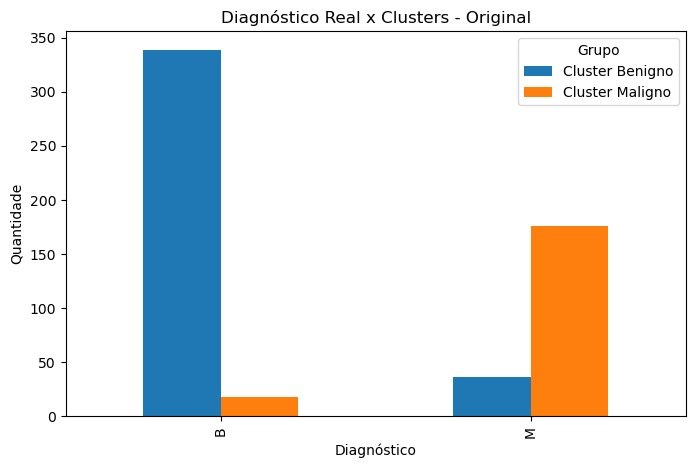

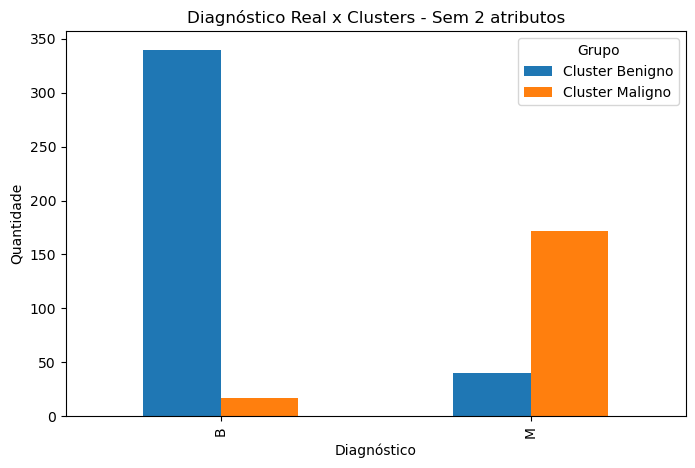

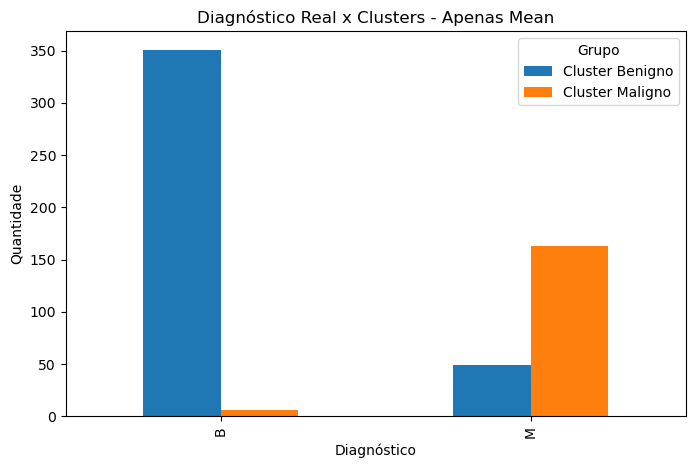

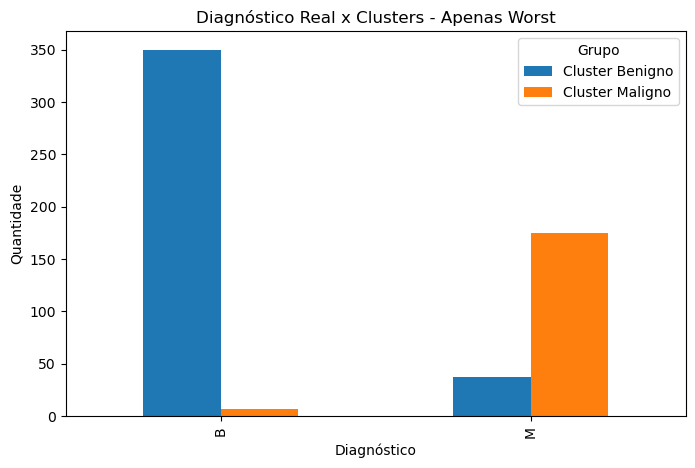

In [24]:
cenarios = {
    "Original": c_original,
    "Sem 2 atributos": c_sem_dois,
    "Apenas Mean": c_mean,
    "Apenas Worst": c_worst,
}

for nome, clusters in cenarios.items():

    # Tabela temporária para descobrir qual cluster é o benigno
    tabela = pd.crosstab(
        df["diagnosis"],
        clusters
    )

    cluster_benigno = tabela.loc["B"].idxmax()

    # Força Cluster 0 = Benigno
    if cluster_benigno == 1:
        clusters = np.where(clusters == 0, 1, 0)

    # Agora gera a tabela já padronizada
    tabela = pd.crosstab(
        df["diagnosis"],
        clusters
    )

    tabela.columns = [
        "Cluster Benigno",
        "Cluster Maligno"
    ]

    tabela.plot(
        kind="bar",
        figsize=(8,5)
    )

    plt.title(f"Diagnóstico Real x Clusters - {nome}")
    plt.xlabel("Diagnóstico")
    plt.ylabel("Quantidade")
    plt.legend(title="Grupo")
    plt.show()

Os gráficos permitem visualizar rapidamente a distribuição dos diagnósticos em cada cluster.

Uma boa separação ocorre quando cada cluster concentra predominantemente um único tipo de diagnóstico.

Caso os diagnósticos apareçam misturados em ambos os grupos, isso indica que o algoritmo teve maior dificuldade para encontrar padrões consistentes.

### Conclusão

Neste trabalho foi utilizado o algoritmo K-Means para realizar agrupamento de dados no conjunto Breast Cancer Wisconsin.

Inicialmente, foi realizado o pré-processamento dos dados, removendo atributos sem relevância para o agrupamento. Em seguida, foram criados diferentes cenários de teste com o objetivo de avaliar o impacto da remoção e seleção de atributos na qualidade dos clusters produzidos.

Os agrupamentos foram avaliados por meio das métricas Silhouette Score, Calinski-Harabasz e Davies-Bouldin. Os resultados permitiram comparar o desempenho de cada cenário e identificar quais conjuntos de atributos produziram grupos mais bem definidos.

Além das métricas tradicionais, os clusters encontrados foram comparados com os diagnósticos reais dos pacientes. Essa análise mostrou o quanto os grupos gerados pelo algoritmo se aproximaram da divisão entre tumores benignos e malignos, mesmo sem utilizar essa informação durante o treinamento.

Os gráficos obtidos através da redução de dimensionalidade com PCA permitiram visualizar a distribuição dos grupos e confirmar visualmente os resultados observados nas métricas.

De forma geral, os experimentos demonstraram que algumas características possuem maior influência na formação dos agrupamentos do que outras. A comparação entre os cenários permitiu avaliar quais atributos contribuem mais para a separação dos tumores e quais podem ser removidos sem causar perdas significativas de desempenho.

Por fim, conclui-se que o algoritmo K-Means foi capaz de identificar padrões relevantes no conjunto de dados e produzir agrupamentos que apresentam relação com os diagnósticos reais, demonstrando o potencial das técnicas de aprendizado não supervisionado na análise exploratória de dados médicos.